In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
clusters = run["clusters"]
markers = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))

Downloading bucket files: 56073178 / 56073178 complete

Downloading bytes: 56073178 / 56073178 complete

In [2]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=markers,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(12)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.61010,0.23971,12.53800,0.60899,2.226800e-107,3.930654e-105
1,ANKRD55,0.55598,0.14931,17.50463,0.56991,8.026462e-73,7.275445e-71
2,FHIT,0.52636,0.62308,10.10307,0.77753,3.175687e-287,3.803792e-284
3,TSHZ2,0.49994,0.32768,6.13078,0.63882,6.159739e-121,1.299279e-118
4,TCEA3,0.49036,0.21550,7.97472,0.59298,4.791068e-80,5.150091e-78
5,CHRM3-AS2,0.46122,0.38095,7.14780,0.66246,3.430929e-144,9.588876e-142
6,AC005842.1,0.44652,0.15981,7.71716,0.56975,1.851000e-61,1.296009e-59
7,CMTM8,0.43404,0.30508,4.73965,0.61923,1.490711e-85,1.915535e-83
8,EPHX2,0.43301,0.39306,6.94567,0.66494,3.037417e-141,8.215234e-139
9,DPYSL4,0.42022,0.10250,17.04981,0.54827,4.016285e-51,2.179582e-49


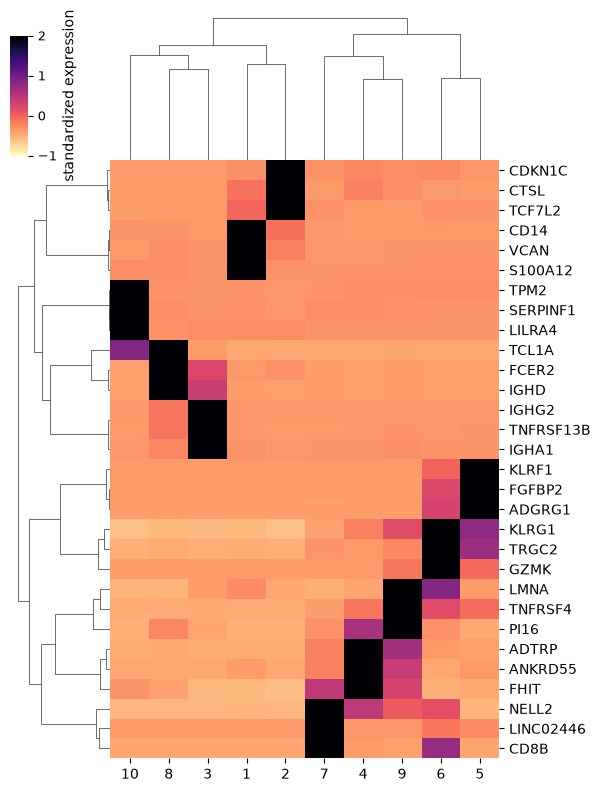

In [3]:
ds.plots.marker_heatmap(
    marker=markers,
    topn=3,
    figsize=(6, 8),
)

In [4]:
label_map = {
    "1": "CD14 monocytes",
    "2": "FCGR3A monocytes",
    "3": "B cells",
    "4": "T cells",
    "5": "NK cells",
    "6": "T cells",
    "7": "T cells",
    "8": "B cells",
    "9": "T cells",
    "10": "pDC-like cells",
}
observed = {str(value) for value in np.unique(cluster_values)}
assert observed == set(label_map)

analysis_cells = np.asarray(run.cells.fetch_all("I"), dtype=bool)
cell_type = np.full(len(analysis_cells), "Not analyzed", dtype=object)
cell_type[analysis_cells] = [label_map[str(value)] for value in cluster_values]
ds.cells.insert("reviewed_cell_type", cell_type, overwrite=True)
pd.Series(cell_type[analysis_cells]).value_counts()

T cells             2386
CD14 monocytes       699
B cells              498
NK cells             317
FCGR3A monocytes      25
pDC-like cells        15
Name: count, dtype: int64

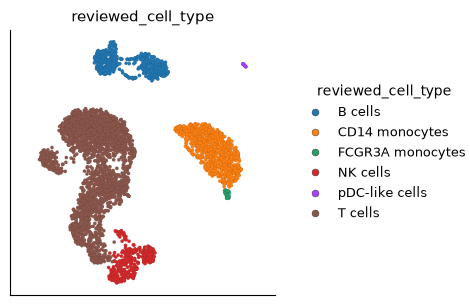

In [5]:
ds.plots.embedding(
    layout=run["umap"],
    color_by="reviewed_cell_type",
    legend_loc="right",
)